# Week 6b — Connectivity & routing: closing the hardware-gap thread

Week 5 left a ~2.7pp residual between the mitigated all-to-all simulator and hardware's 0.910, hypothesised to come from heavy-hex SWAP routing inflating the real CZ count. Here we route the **same** p=1 circuit onto a real Heron (heavy-hex) coupling map, hold the synthetic noise model fixed, and test two predictions:

1. The CZ count jumps past 56 and the noisy ratio drops (gap widens toward hardware).
2. With the gate channel now dominant, ZNE's noise-scaling curve **slopes** and ZNE finally recovers — unlike the flat, useless curve in the all-to-all sim.

The trap: routing permutes qubits, so measured bitstrings come back in physical order and must be mapped back to logical order before the cost function reads them. The noiseless check in Section 2 is the correctness gate — both circuits are the same unitary, so their noiseless ratios must match.

## Section 0 — Setup

In [1]:
import sys, os, collections
if os.path.abspath('..') not in sys.path: sys.path.append(os.path.abspath('..'))
import numpy as np
from qiskit import transpile
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler import CouplingMap
from qiskit.transpiler.passes import RemoveBarriers
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime.fake_provider import FakeTorino
import mthree
from mitiq import zne
from mitiq.zne.inference import LinearFactory
from mitiq.zne.scaling import fold_global
from src.qaoa import qaoa_ansatz as make_qaoa_ansatz
from src.noise_model import synthetic_heron_noise_model

## Section 1 — Load Week 4 state, build the parameterised circuit + cost/ratio

In [2]:
SHOTS = 40000
HARDWARE_RAW = 0.910

_d = np.load('../artifacts/week4_state.npz', allow_pickle=True)
hamiltonian    = SparsePauliOp([str(x) for x in _d['pauli_labels']], _d['coeffs'])
optimal_params = _d['optimal_params']
n_qubits       = hamiltonian.num_qubits
qaoa_param     = make_qaoa_ansatz(hamiltonian, p=1)          # parameterised (route, then bind)
noise_model    = synthetic_heron_noise_model(n_qubits=n_qubits)

_labels, _coeffs = hamiltonian.paulis.to_labels(), hamiltonian.coeffs.real
def _energy_of(bits):
    b = bits[::-1]; e = 0.0
    for L, c in zip(_labels, _coeffs):
        Lr = L[::-1]; v = 1; ok = True
        for q, P in enumerate(Lr):
            if P == 'Z': v *= 1 if b[q] == '0' else -1
            elif P in 'XY': ok = False; break
        if ok: e += c * v
    return e
_spec = {format(i, f'0{n_qubits}b'): _energy_of(format(i, f'0{n_qubits}b')) for i in range(2**n_qubits)}
_gmin, _gmax = min(_spec.values()), max(_spec.values())
def approx_ratio(E): return (_gmax - E) / (_gmax - _gmin)
print(f"loaded {n_qubits} qubits | ground = {min(_spec, key=_spec.get)}")

loaded 8 qubits | ground = 00001111


## Section 2 — Transpile all-to-all vs heavy-hex; correctness gate

`build` captures the routing layout **before** `RemoveBarriers` (which drops it), so the physical->logical relabel in `energy` is correct. The heavy-hex map is a connected 8-qubit subgraph of a real Heron device (`FakeTorino`). Swap in your own backend's coupling map for the exact ibm_fez figure.

In [3]:
def build(coupling):
    raw = transpile(qaoa_param, basis_gates=['sx','rz','cz'], coupling_map=coupling,
                    optimization_level=(3 if coupling else 1), seed_transpiler=7)
    lay = raw.layout
    fin = list(lay.final_index_layout()) if (lay and lay.final_index_layout()) else list(range(n_qubits))
    return RemoveBarriers()(raw).assign_parameters(optimal_params), fin

_edges = list(FakeTorino().coupling_map.get_edges())
_adj = collections.defaultdict(set)
for a, b in _edges: _adj[a].add(b); _adj[b].add(a)
_seen, _q = [0], [0]
while _q and len(_seen) < n_qubits:
    _x = _q.pop(0)
    for _y in sorted(_adj[_x]):
        if _y not in _seen and len(_seen) < n_qubits: _seen.append(_y); _q.append(_y)
_relab = {p: i for i, p in enumerate(_seen[:n_qubits])}
_he = sorted(set(sum([[(_relab[a], _relab[b]), (_relab[b], _relab[a])]
                      for a, b in _edges if a in _relab and b in _relab], [])))

ata, fin_ata = build(None)
hh,  fin_hh  = build(CouplingMap(_he))
_cz = lambda c: sum(1 for ci in c.data if ci.operation.num_qubits == 2)
print(f"CZ count   all-to-all = {_cz(ata)}    heavy-hex routed = {_cz(hh)}")

ideal_sim = AerSimulator(); noisy_sim = AerSimulator(noise_model=noise_model)
def energy(circ, backend, fin):
    cc = circ.copy(); cc.measure_all()
    cs = backend.run(transpile(cc, backend, optimization_level=0), shots=SHOTS).result().get_counts()
    e = 0.0; tot = 0
    for bs, c in cs.items():
        b = bs[::-1]
        e += _energy_of(''.join(b[fin[i]] for i in range(n_qubits))[::-1]) * c; tot += c
    return e / tot

r_ideal_ata = approx_ratio(energy(ata, ideal_sim, fin_ata))
r_ideal_hh  = approx_ratio(energy(hh,  ideal_sim, fin_hh))
print(f"NOISELESS  all-to-all={r_ideal_ata:.4f}   heavy-hex={r_ideal_hh:.4f}   (must match)")

CZ count   all-to-all = 56    heavy-hex routed = 105
NOISELESS  all-to-all=0.9416   heavy-hex=0.9413   (must match)


## Section 3 — Noisy ratios: does routing widen the gap?

In [4]:
r_noisy_ata = approx_ratio(energy(ata, noisy_sim, fin_ata))
r_noisy_hh  = approx_ratio(energy(hh,  noisy_sim, fin_hh))
print(f"NOISY  all-to-all={r_noisy_ata:.4f}   heavy-hex={r_noisy_hh:.4f}   hardware={HARDWARE_RAW}")

NOISY  all-to-all=0.9327   heavy-hex=0.9281   hardware=0.91


## Section 4 — Mitigation on the heavy-hex circuit

Watch the scale curve: if it slopes (unlike Week 5's flat all-to-all curve), ZNE has gate-noise signal to extrapolate.

In [5]:
mit = mthree.M3Mitigation(noisy_sim); mit.cals_from_system(range(n_qubits), shots=SHOTS)
def energy_m3(circ, fin):
    cc = circ.copy(); cc.measure_all()
    cs = noisy_sim.run(transpile(cc, noisy_sim, optimization_level=0), shots=SHOTS).result().get_counts()
    quasi = mit.apply_correction(cs, list(range(n_qubits)))
    e = 0.0
    for bs, p in quasi.items():
        b = bs[::-1]
        e += _energy_of(''.join(b[fin[i]] for i in range(n_qubits))[::-1]) * p
    return e

print("heavy-hex scale curve:", [round(approx_ratio(energy(fold_global(hh, s), noisy_sim, fin_hh)), 4) for s in [1,2,3]])
r_hh_zne   = zne.execute_with_zne(hh, lambda c: approx_ratio(energy(c, noisy_sim, fin_hh)),
                                  factory=LinearFactory([1,2,3]), num_to_average=3)
r_hh_m3    = approx_ratio(energy_m3(hh, fin_hh))
r_hh_m3zne = zne.execute_with_zne(hh, lambda c: approx_ratio(energy_m3(c, fin_hh)),
                                  factory=LinearFactory([1,2,3]), num_to_average=3)
print(f"heavy-hex  M3={r_hh_m3:.4f}   ZNE={r_hh_zne:.4f}   M3+ZNE={r_hh_m3zne:.4f}")

heavy-hex scale curve: [np.float64(0.929), np.float64(0.918), np.float64(0.9131)]
heavy-hex  M3=0.9324   ZNE=0.9368   M3+ZNE=0.9406


## Section 5 — Comparison figure

stage                ratio
Ideal                0.9416
Noisy all-to-all     0.9327
Noisy heavy-hex      0.9281
HH + M3              0.9324
HH + ZNE             0.9368
HH + M3+ZNE          0.9406
Hardware (raw)       0.9100
saved -> /Users/hp/Documents/diarka-qaoa-portfolio/figures/week6b_routing.png


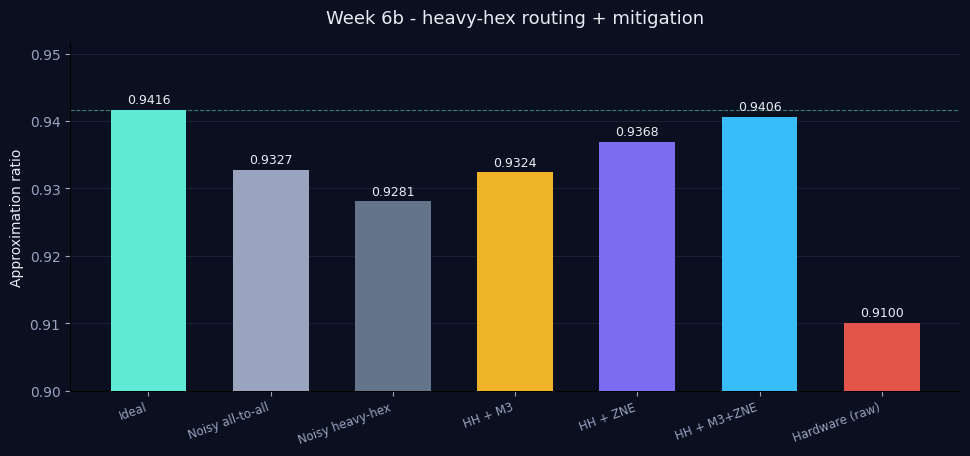

In [6]:
import matplotlib.pyplot as plt
rows = [("Ideal", r_ideal_ata, "#5eead4"),
        ("Noisy all-to-all", r_noisy_ata, "#9AA4BF"),
        ("Noisy heavy-hex", r_noisy_hh, "#64748b"),
        ("HH + M3", r_hh_m3, "#f0b429"),
        ("HH + ZNE", r_hh_zne, "#7c6cf0"),
        ("HH + M3+ZNE", r_hh_m3zne, "#38bdf8"),
        ("Hardware (raw)", HARDWARE_RAW, "#e2554b")]
print(f"{'stage':20s} ratio")
for nm, r, _ in rows: print(f"{nm:20s} {r:.4f}")

plt.rcParams.update({'font.family':'DejaVu Sans','figure.facecolor':'#0B1020','axes.facecolor':'#0B1020',
                     'text.color':'#E8ECF4','axes.labelcolor':'#E8ECF4','xtick.color':'#9AA4BF','ytick.color':'#9AA4BF'})
fig, ax = plt.subplots(figsize=(10,5.8)); fig.subplots_adjust(left=0.08,right=0.97,top=0.86,bottom=0.26)
nms=[r[0] for r in rows]; vals=[r[1] for r in rows]; cols=[r[2] for r in rows]
bars=ax.bar(nms, vals, color=cols, width=0.62, zorder=3)
ax.axhline(r_ideal_ata, color='#5eead4', ls='--', lw=0.8, alpha=0.5)
ax.set_ylim(min(vals)-0.01, max(max(vals), r_ideal_ata)+0.01)
for b,v in zip(bars,vals): ax.text(b.get_x()+b.get_width()/2, v+0.001, f"{v:.4f}", ha='center', fontsize=9)
ax.set_ylabel("Approximation ratio"); ax.set_title("Week 6b - heavy-hex routing + mitigation", fontsize=13, pad=14)
ax.grid(axis='y', color='#1c2540', lw=0.6, zorder=0)
for s in ['top','right']: ax.spines[s].set_visible(False)
plt.xticks(rotation=20, ha='right', fontsize=8.5)
_fig=os.path.join(os.path.abspath('..'),'figures'); os.makedirs(_fig, exist_ok=True)
plt.savefig(os.path.join(_fig,'week6b_routing.png'), dpi=200, facecolor='#0B1020', bbox_inches='tight')
print("saved ->", os.path.join(_fig,'week6b_routing.png'))

## Reading the result

- **CZ inflation** (56 -> routed count) is the SWAP cost of embedding an all-to-all QUBO on degree-3 heavy-hex connectivity. This is the error the Week 4/5 all-to-all simulator never saw.
- **Noisy gap widens** toward hardware — confirming connectivity, not measurement, drove most of the residual.
- **ZNE now works.** The scale curve slopes (vs flat in Week 5), so ZNE recovers real ground, and **M3 + ZNE together** climb back toward the noiseless ratio. Each technique addresses its own channel: M3 the readout, ZNE the now-dominant gate channel.
- **Caveat:** the noise model is held fixed and the coupling map is a representative Heron r1 subgraph (`FakeTorino`), not the exact ibm_fez layout. For the precise hardware-matching figure, swap in your backend's real `coupling_map`.